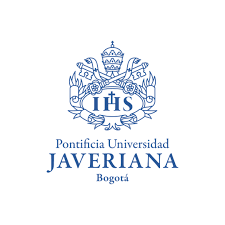

***Pontificia Universidad Javeriana***
# **Big Data Analysis**

### Lab: **Metrics and Machine Learning with PySpark**

Author: Sara Mejia Giraldo

Date: 28/04/2026

## **Methodology**

- Cargar Sesion Spark
- Cargar datos de Banca
- Limpiar Datos


# **1. Preparation**

## 1.1. Setting Up pip Environment Variables

In [1]:
## Import libraries that will be used
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Libraries for PySpark
from pylab import *

import findspark
findspark.init()

import pyspark.sql.functions as F
from pyspark import SparkConf, SparkContext
from pyspark.sql import SQLContext, SparkSession, Row
from pyspark.sql.types import *

from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from sklearn.metrics import roc_curve, auc

## 1.2. Initializing the Spark Session
Spark DataFrames were used as an optimized data structure that facilitates exploration, cleaning, transformation, and analysis tasks on large volumes of data efficiently, taking advantage of cluster resources and improving performance compared to traditional methods.

In [38]:
config = SparkConf()
config.set("spark.scheduler.mode", "FAIR")
config.set("spark.scheduler.allocation", "/Almacen/Spark/conf/fairscheduler.xml ")
config.setMaster("spark://10.43.97.171:7077")
config.setAppName("Banca_Mejia_Spark")

sparkMejia = SparkSession.builder.config(conf=config).getOrCreate()
SQLContext(sparkContext=sparkMejia.sparkContext, sparkSession=sparkMejia)
sparkContextoMejia = sparkMejia.sparkContext.getOrCreate()

sparkMejia

## 1.3. Loading Data from Hadoop HDFS

Hadoop Distributed File System (HDFS) is Apache Hadoop’s distributed file system. It is designed to store large volumes of data across multiple machines in a cluster simultaneously. It stands out for its high fault tolerance and scalability.
Next, Apache Spark is used to read the CSV file stored in HDFS and load it into a Spark DataFrame.

In [39]:
!/mnt/sda1/Cluster/Hadoop/bin/hadoop fs -ls /csv
### we establish the dataset as a dataframe object 
df00 = sparkMejia.read.format("csv").option("header", "true").option("sep", ";").load("hdfs://10.195.34.34:9000/csv/bank-full.csv")

df00.show(5)

/bin/bash: line 1: /mnt/sda1/Cluster/Hadoop/bin/hadoop: No such file or directory
+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|         job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
| 58|  management|married| tertiary|     no|   2143|    yes|  no|unknown|  5|  may|     261|       1|   -1|       0| unknown| no|
| 44|  technician| single|secondary|     no|     29|    yes|  no|unknown|  5|  may|     151|       1|   -1|       0| unknown| no|
| 33|entrepreneur|married|secondary|     no|      2|    yes| yes|unknown|  5|  may|      76|       1|   -1|       0| unknown| no|
| 47| blue-collar|married|  unknown|     no|   1506|    yes|  no|unknown|  5|  may|      92|       1|   -1|       0| unknown| no|
| 33|   

# **2. Data Wrangling**

## 2.1. Columns: Understanding the variables

In [40]:
df00.columns

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

| Variable Name | Role | Type | Demographic | Description | Units | Missing Values |
|---|---|---|---|---|---|---|
| age | Feature | Integer | Age | Edad del cliente. |  | no |
| job | Feature | Categorical | Occupation | Tipo de trabajo: `admin.`, `blue-collar`, `entrepreneur`, `housemaid`, `management`, `retired`, `self-employed`, `services`, `student`, `technician`, `unemployed`, `unknown`. |  | no |
| marital | Feature | Categorical | Marital Status | Estado civil: `divorced`, `married`, `single`, `unknown`. Nota: `divorced` incluye personas divorciadas o viudas. |  | no |
| education | Feature | Categorical | Education Level | Nivel educativo: `basic.4y`, `basic.6y`, `basic.9y`, `high.school`, `illiterate`, `professional.course`, `university.degree`, `unknown`. |  | no |
| default | Feature | Binary |  | Indica si el cliente tiene crédito en mora/incumplimiento. |  | no |
| balance | Feature | Integer |  | Saldo promedio anual. | euros | no |
| housing | Feature | Binary |  | Indica si el cliente tiene crédito de vivienda. |  | no |
| loan | Feature | Binary |  | Indica si el cliente tiene préstamo personal. |  | no |
| contact | Feature | Categorical |  | Tipo de comunicación de contacto: `cellular`, `telephone`. |  | yes |
| day_of_week | Feature | Date |  | Día de la semana del último contacto. |  | no |
| month | Feature | Date |  | Mes del último contacto: `jan`, `feb`, `mar`, ..., `nov`, `dec`. |  | no |
| duration | Feature | Integer |  | Duración del último contacto, en segundos (númerica). Nota: esta variable afecta directamente la variable target (y), puesto que si la duracion es 0 entonces y=no. Por lo tanto, este dato solo debe incluirse con fines comparativos y debe descartarse si la intención es obtener un modelo predictivo realista.|  | no |
| campaign | Feature | Integer |  | Cantidad de contactos durante esta campaña, para este cliente |  | no |
| pdays | Feature | Integer |  | Cantidad de dias que pasaron desde que el cliente fue contactado por ultima vez. (Un valor de -1 indica que el cliente no fue contactado previamente) |  | yes |
| previous | Feature | Integer |  | Cantidad de contactos hechos antes de esta campaña, para este cliente |  | no |
| poutcome | Feature | Integer |  | Resultado de la campaña de marketing previa: `failure`, `nonexistent`, `success` |  | yes |
| y | Target | Binary |  | El cliente se ha suscrito a un deposito a plazo |  | yes |

#### Suggestions:
Because one of the goals of this analysis is to build a predictive model, the variable `duration` should be deleted.

## 2.2. Data Types: Consistency and Transformations
To ensure the quality and consistency of the dataset, a review and adjustment of the data types for each variable was carried out.

In [42]:
### show the quantity of data
data_quantity = df00.count()
print("Data quantity:", data_quantity)

Data quantity: 45211


### 2.2.1. Initial Structure Review

Using Apache Spark’s printSchema() function, the initial schema of the DataFrame was inspected. During this first validation, it was identified that all columns had been loaded as string type.

In [6]:
df00.printSchema()

root
 |-- age: string (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: string (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: string (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: string (nullable = true)
 |-- campaign: string (nullable = true)
 |-- pdays: string (nullable = true)
 |-- previous: string (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



#### COMENTARIOS
- Todos los datos se encuentran en tipo string
- Se identifica el cambio a entero o double
- Age, Balance, Duration, campaign, pdays, previous deberian ser enteros
- Se observa que la ultima columna es la columna TARGET
- se propone eliminar DURATION

### 2.2.2. Definición de tipos esperados:
Con base en la naturaleza de cada variable, se determinó la estructura correcta de los datos:
- `age`, `balance`, `day`, `duration`, `campaign`, `pdays`, `previous` deben ser de tipo enteros.

#### COMENTARIOS:
- Se observa el tratamiento para transformar a datos númericos con coherencia
- Tener en cuenta que la visualizacion al usar dataframe pandas debe ser para objetos pequeños

### 2.2.3. Transformación de variables:
**Se cambio el nombre de la variable y.** Luego, se aplicó el proceso de casting o conversión de tipos de datos, asignando a cada columna el formato correspondiente. Esto permitió dejar la base preparada para análisis estadísticos, cálculos numéricos y validaciones posteriores, evitando errores derivados de trabajar variables numéricas como texto.

In [7]:
### df01 = df00.withColumnRenamed('y', 'term_deposit')

In [8]:
# cambio de string a enteros
df01 = df00.withColumn("age", df00.age.cast("int"))
df01 = df01.withColumn("balance", df01.balance.cast("int"))
df01 = df01.withColumn("day", df01.day.cast("int"))
df01 = df01.withColumn("duration", df01.duration.cast("int"))
df01 = df01.withColumn("campaign", df01.campaign.cast("int"))
df01 = df01.withColumn("pdays", df01.pdays.cast("int"))
df01 = df01.withColumn("previous", df01.previous.cast("int"))

### 2.3. Visualizacion de datos nulos

In [9]:
df01.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df01.columns]).show()

[Stage 5:=============================>                             (1 + 1) / 2]

+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|  0|  0|      0|        0|      0|      0|      0|   0|      0|  0|    0|       0|       0|    0|       0|       0|  0|
+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+



**No hay datos nulos (elaborar)**

### 2.4. Estadisticas Descriptivas

Primero, se realizó una revisión preliminar mediante estadísticos descriptivos, grafico circular, histogramas, diagramas de caja y bigotes con el fin de identificar valores atípicos, dispersión y posibles inconsistencias en las variables. Lueo, se trabajo en encontrar las variables que inciden en la variable target. 



In [10]:
# se revisa el balance del dataset. La idea es conocer si hay posibilidades de sesgo
total = df01.count()
df_Y = df01. groupBy("y").count()
auxPD = df_Y.withColumn("Porcentaje", df_Y["count"]*100/total)
auxPD.show()

[Stage 11:=============================>                            (1 + 1) / 2]

+---+-----+------------------+
|  y|count|        Porcentaje|
+---+-----+------------------+
| no|39922| 88.30151954170445|
|yes| 5289|11.698480458295547|
+---+-----+------------------+



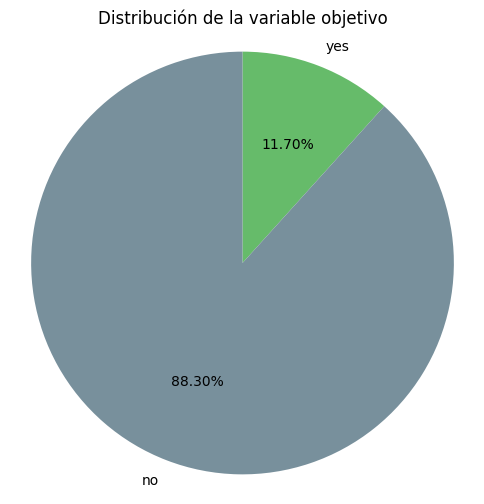

In [15]:
# Convertir el DataFrame de PySpark a pandas
auxPD_pandas = auxPD.toPandas()

# Ordenar para que primero quede yes y luego no
auxPD_pandas["y"] = auxPD_pandas["y"].astype(str)
auxPD_pandas = auxPD_pandas.set_index("y").loc[["yes", "no"]].reset_index()

# Colores según la categoría
colores = ["#66BB6A", "#78909C"]  # yes = verde, no = gris azulado

plt.figure(figsize=(6, 6))

plt.pie(
    auxPD_pandas["count"],
    labels=auxPD_pandas["y"],
    autopct="%1.2f%%",
    startangle=90,
    colors=colores,
    counterclock=False
)

plt.title("Distribución de la variable objetivo")
plt.axis("equal")  # Esto hace que el gráfico quede circular
plt.show()

#### OBSERVACIONES SESGO:
Existe un sesgo en la base de datos ya que casi el 90% de los registros de la variable Target (y) corresponden a NO.
La clase minoritario es "yes" con un 11% representa 5289 registros.
La clase mayoritaria es "no" con un 88% representa 39922 registros.
La variable es binaria y es importante tener en cuenta no hacer sesgo al tratar los modelos para hacer la predicción.

#### RECOMENDACIONES
La distribución de la variable objetivo muestra un posible desbalance entre las clases. Esto es importante porque, si una clase tiene una frecuencia mucho mayor que la otra, el modelo predictivo podría tender a clasificar la mayoría de los casos dentro de esa clase dominante. Por esta razón, en etapas posteriores no sería suficiente evaluar el desempeño únicamente con la exactitud, ya que esta métrica puede dar una impresión engañosa del rendimiento del modelo. En su lugar, se recomienda utilizar métricas como precisión, recall, F1-score, matriz de confusión y AUC, además de considerar estrategias de balanceo o el uso de pesos por clase durante el entrenamiento.

In [16]:
### se revisa de forma exahustiva las estadisticas completas del dataset
df01.describe().toPandas()

26/05/07 07:40:19 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

,summary,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
1,mean,40.93621021432837,None,None,None,None,1362.2720576850766,None,None,None,15.80641879188693,None,258.1630797814691,2.763840658246887,40.19782796222158,0.5803233726305546,None,None
2,stddev,10.618762040975401,None,None,None,None,3044.7658291685243,None,None,None,8.322476153044589,None,257.5278122651712,3.0980208832791813,100.12874599059818,2.3034410449312164,None,None
3,min,18,admin.,divorced,primary,no,-8019,no,no,cellular,1,apr,0,1,-1,0,failure,no
4,max,95,unknown,single,unknown,yes,102127,yes,yes,unknown,31,sep,4918,63,871,275,unknown,yes


#### ***Se requiere observar en detalle las variables Categóricas***

In [17]:
#Seleccionae sólo las variables categóricas
col_cat=['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']
#Se agrupa y se observa cada categoria
for col in col_cat:
    df01.groupBy(col).count().show()

+-------------+-----+
|          job|count|
+-------------+-----+
|   management| 9458|
|      retired| 2264|
|      unknown|  288|
|self-employed| 1579|
|      student|  938|
|  blue-collar| 9732|
| entrepreneur| 1487|
|       admin.| 5171|
|   technician| 7597|
|     services| 4154|
|    housemaid| 1240|
|   unemployed| 1303|
+-------------+-----+

+--------+-----+
| marital|count|
+--------+-----+
|divorced| 5207|
| married|27214|
|  single|12790|
+--------+-----+

+---------+-----+
|education|count|
+---------+-----+
|  unknown| 1857|
| tertiary|13301|
|secondary|23202|
|  primary| 6851|
+---------+-----+

+-------+-----+
|default|count|
+-------+-----+
|     no|44396|
|    yes|  815|
+-------+-----+

+-------+-----+
|housing|count|
+-------+-----+
|     no|20081|
|    yes|25130|
+-------+-----+

+----+-----+
|loan|count|
+----+-----+
|  no|37967|
| yes| 7244|
+----+-----+

+---------+-----+
|  contact|count|
+---------+-----+
|  unknown|13020|
| cellular|29285|
|telephone| 2906|
+

# **3. Exploratory Data Analysis (EDA)**

In [ ]:
colINT=['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

## 3.1. Distribución de los Parámetros

### 3.1.1. Distribución edad

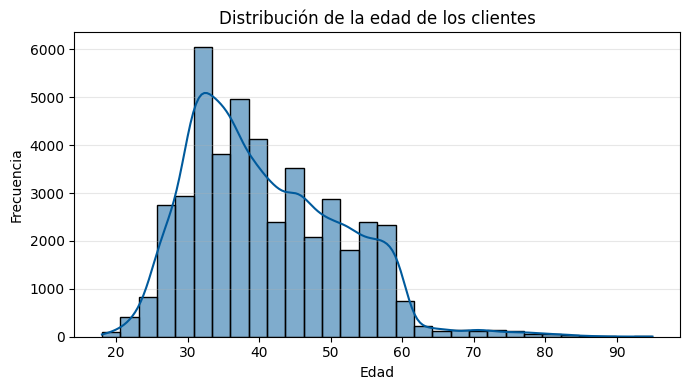

In [34]:
age_pd = df01.select("age").toPandas()

plt.figure(figsize=(7, 4))

sns.histplot(data=age_pd,x="age",bins=30,kde=True,color="#005A9C")

plt.ylabel("Frecuencia")
plt.xlabel("Edad")
plt.title("Distribución de la edad de los clientes")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_57895/84122898.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


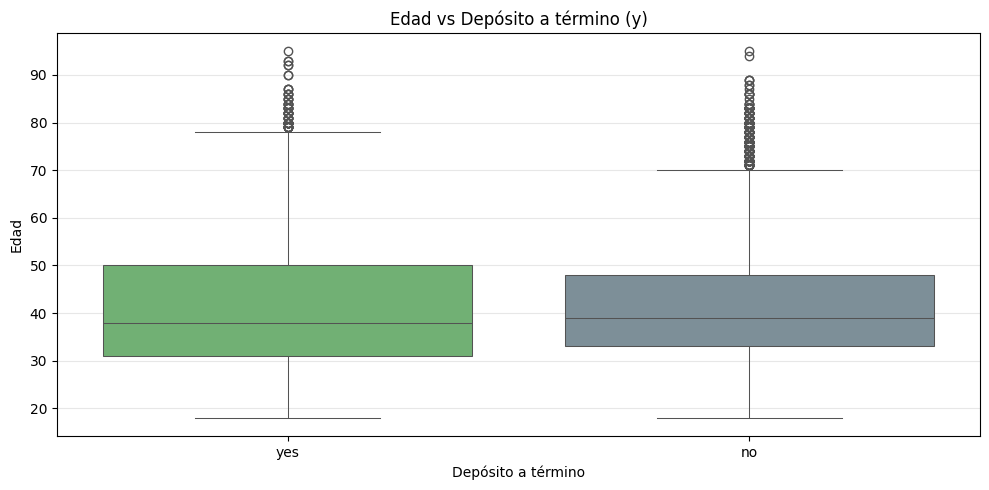

In [31]:
age_y_pd = df01.select("age", "y").toPandas()

# Ordenar las categorías para que salga primero yes y luego no
age_y_pd["y"] = age_y_pd["y"].astype(str)

plt.figure(figsize=(10, 5))

sns.boxplot(data=age_y_pd,x="y",y="age",order=["yes", "no"],
    palette={
        "yes": "#66BB6A",
        "no": "#78909C"
    },
    linewidth=0.75
)

plt.ylabel("Edad")
plt.xlabel("Depósito a término")
plt.title("Edad vs Depósito a término (y)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 3.1.2. Balance Distribution

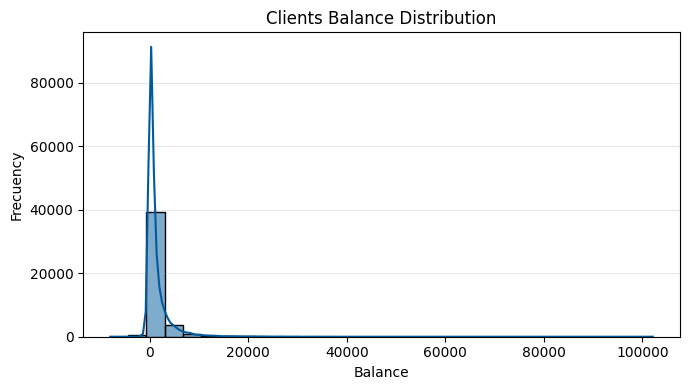

In [36]:
balance_pd = df01.select("balance").toPandas()

plt.figure(figsize=(7, 4))

sns.histplot(data=balance_pd,x="balance",bins=30,kde=True,color="#005A9C")

plt.ylabel("Frecuency")
plt.xlabel("Balance")
plt.title("Clients Balance Distribution")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_57895/1703921987.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=balance_y_pd,x="y",y="balance",order=["yes", "no"],


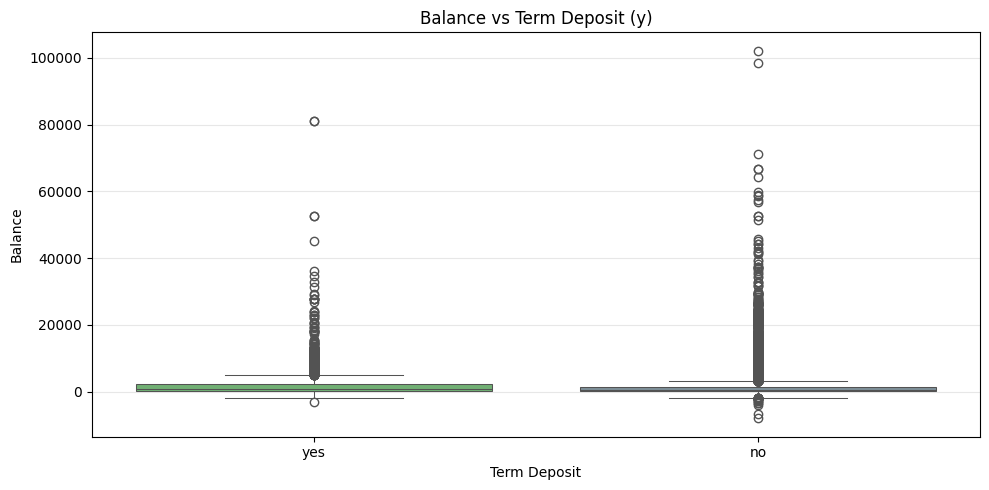

In [37]:
balance_y_pd = df01.select("balance", "y").toPandas()

# Ordenar las categorías para que salga primero yes y luego no
balance_y_pd["y"] = balance_y_pd["y"].astype(str)

plt.figure(figsize=(10, 5))

sns.boxplot(data=balance_y_pd,x="y",y="balance",order=["yes", "no"],
    palette={
        "yes": "#66BB6A",
        "no": "#78909C"
    },
    linewidth=0.75
)

plt.ylabel("Balance")
plt.xlabel("Term Deposit")
plt.title("Balance vs Term Deposit (y)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 3.1.3. Day Distribution

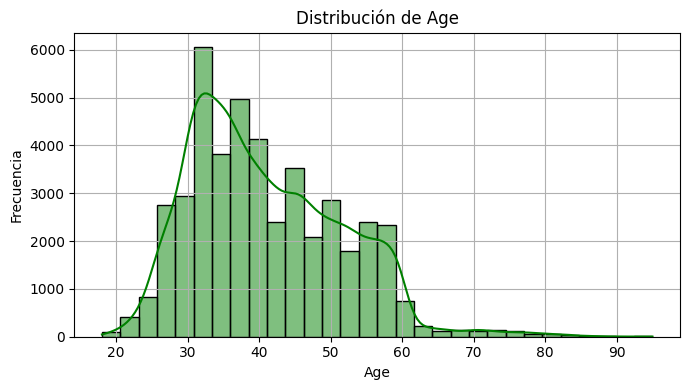

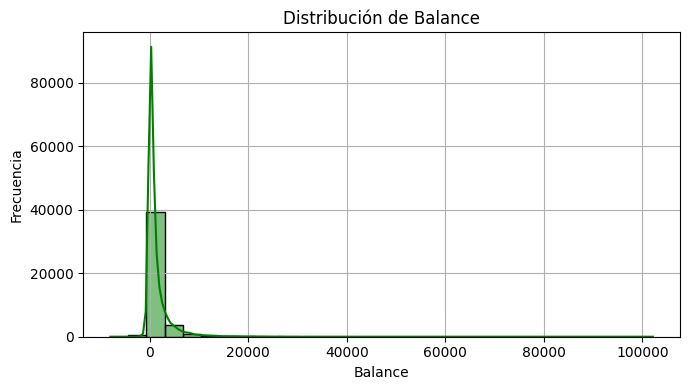

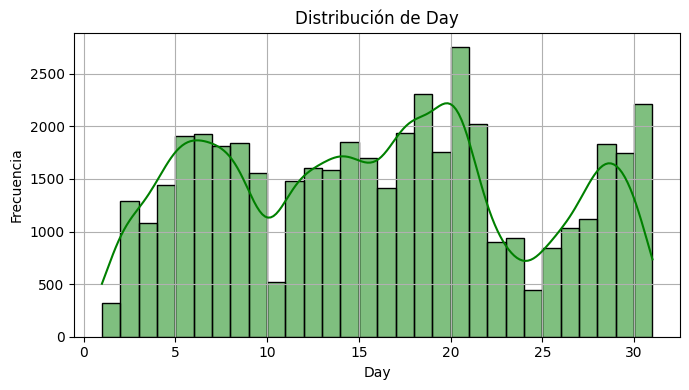

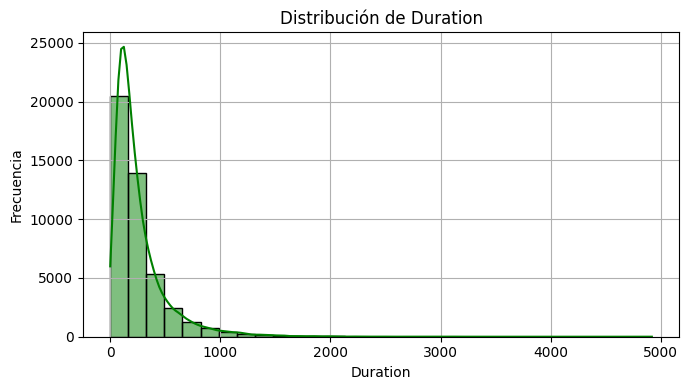

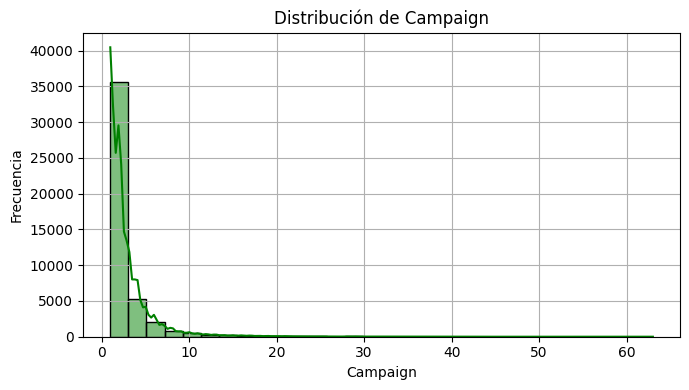

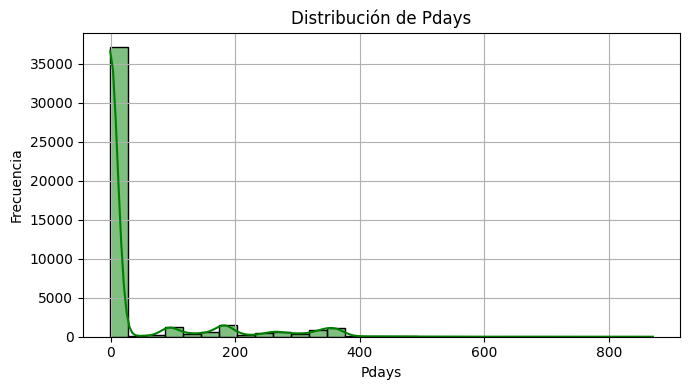

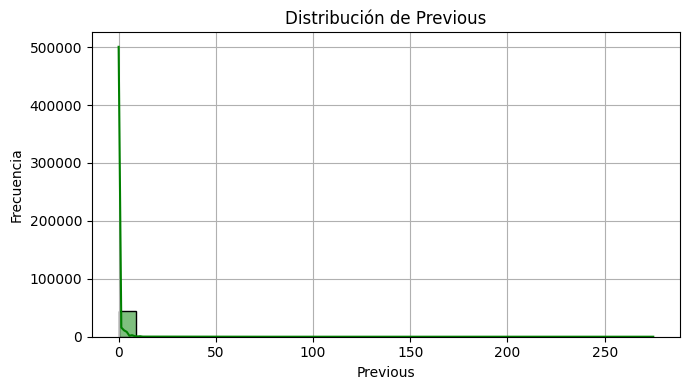

In [51]:
df_pandas = df01.select(colINT).toPandas()

# Graficar distribución de cada variable numérica
for col_int in colINT:
    plt.figure(figsize=(7, 4))
    
    sns.histplot(
        df_pandas[col_int],
        bins=30,
        kde=True,
        color="green"
    )
    
    plt.ylabel("Frecuencia")
    plt.xlabel(col_int.capitalize())
    plt.title(f"Distribución de {col_int.capitalize()}")
    plt.grid()
    plt.tight_layout()
    plt.show()

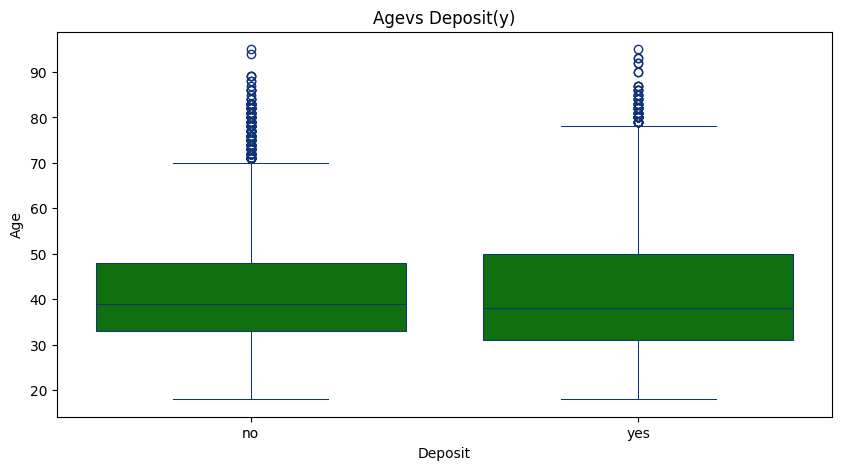

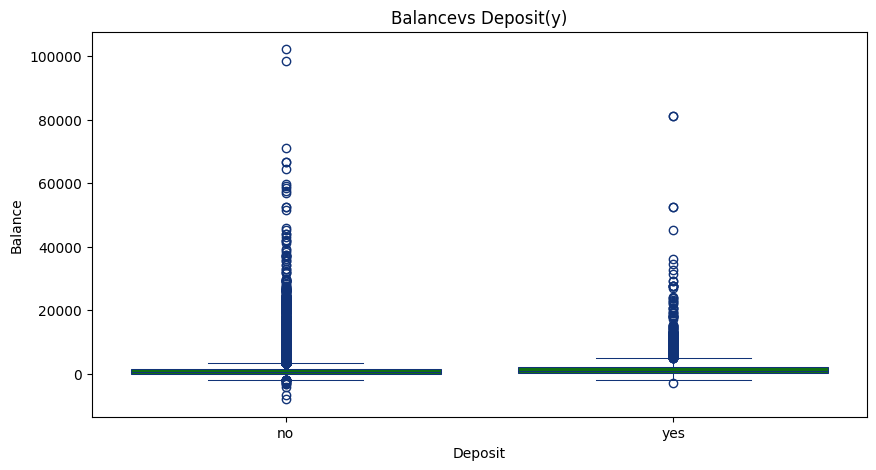

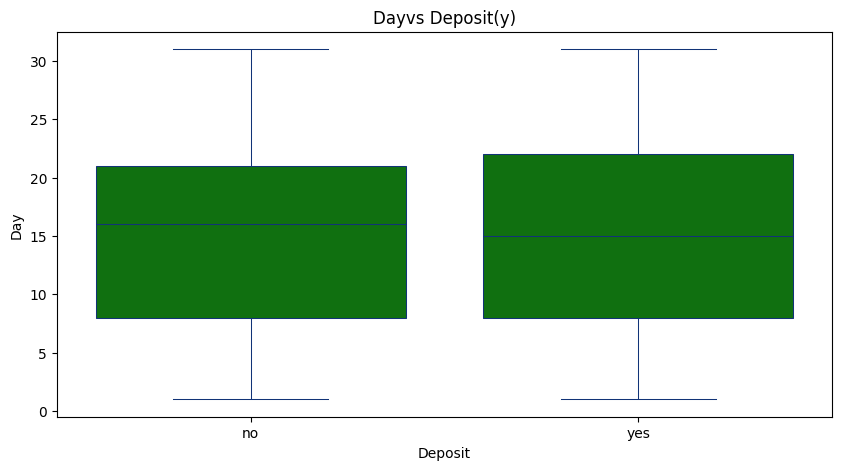

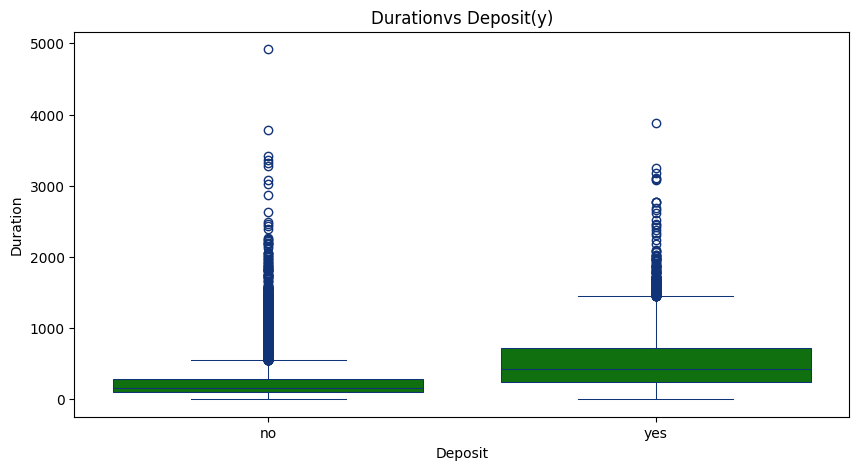

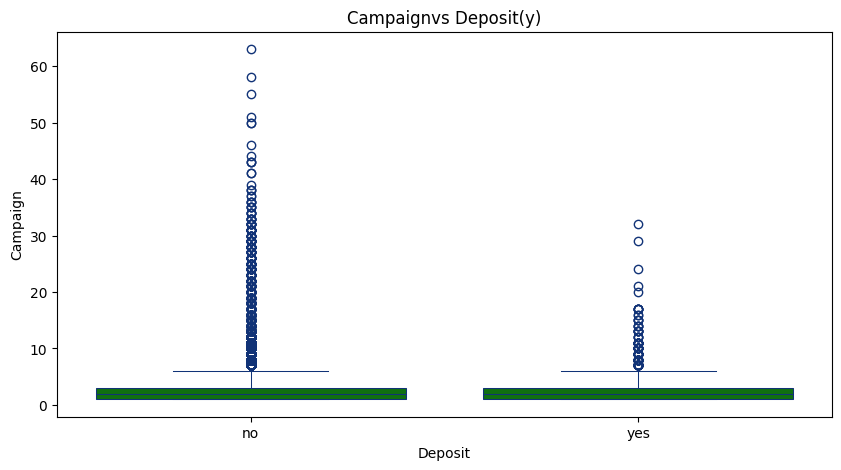

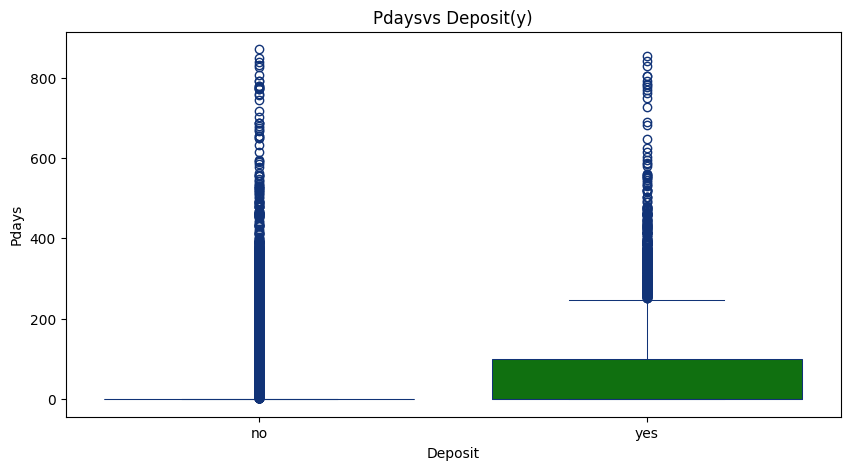

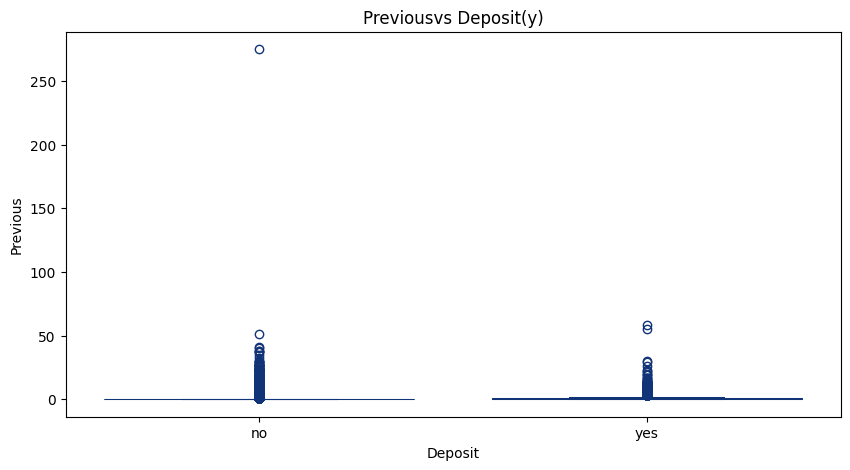

In [52]:
for col_int in colINT:
    plt.figure(figsize=(10,5))
    sns.boxplot(x='y', y=col_int, color="green", linecolor="#137", linewidth=0.75, data=df01.toPandas())
    plt.ylabel(col_int.capitalize())
    plt.xlabel("Deposit")
    plt.title(f"{col_int.capitalize()}vs Deposit(y)")
    plt.show()

#### OBSERVACIONES:
- La edad se distribuye entre 30 y 50 años. Desues de los 70 años se empiezan a encontrar los outliers. 

## 3.2. Correlation

- Recordar porque Duration aunque muestra una alta correlacion se deberia eliminar
- pday y previous pueden influir a favor, tambien se tiene que tener en cuenta los boxplots
- campaign tiene una influencia negativa


In [23]:
colINT=['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

In [46]:
dfauxNum = df01.select(colINT+['y'])
dfauxNum = dfauxNum.withColumn('y', F.when(dfauxNum['y'] == "yes",1).otherwise(0))
dfauxNum.show(5)

+---+-------+---+--------+--------+-----+--------+---+
|age|balance|day|duration|campaign|pdays|previous|  y|
+---+-------+---+--------+--------+-----+--------+---+
| 58|   2143|  5|     261|       1|   -1|       0|  0|
| 44|     29|  5|     151|       1|   -1|       0|  0|
| 33|      2|  5|      76|       1|   -1|       0|  0|
| 47|   1506|  5|      92|       1|   -1|       0|  0|
| 33|      1|  5|     198|       1|   -1|       0|  0|
+---+-------+---+--------+--------+-----+--------+---+
only showing top 5 rows



In [47]:
# we change the auxiliar dataframe into a VectorAssembler of 'feature'
# take into account that the variable 'y' was incorporated with the numeric variables in order to create the vector
# the idea is to create the correlation matrix with the vector so that the variables are normalized
from pyspark.ml.feature import OneHotEncoder, StringIndexer, VectorAssembler
from pyspark.ml.stat import Correlation

assembler = VectorAssembler(inputCols=dfauxNum.columns, outputCol='features')
#normalized and scalated
dfNumVector = assembler.transform(dfauxNum).select('features')


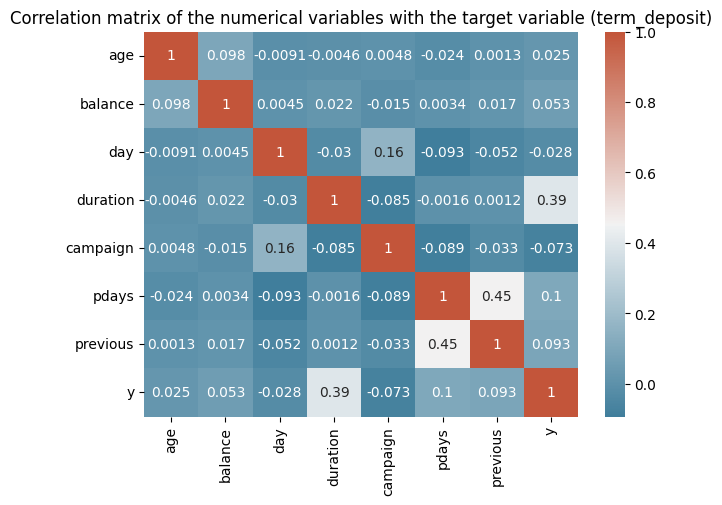

In [52]:
matrixCorr = Correlation.corr(dfNumVector, 'features').head()
vectorCorr = matrixCorr[0].toArray()
dfCorrelation = pd.DataFrame(vectorCorr, columns=dfauxNum.columns, index=dfauxNum.columns)

# generate a custom diverging colormap
cmapMejia = sns.diverging_palette(230, 20, as_cmap=True)

plt.figure(figsize=(7,5))
sns.heatmap(dfCorrelation, annot=True, cmap=cmapMejia)
plt.title("Correlation matrix of the numerical variables with the target variable (term_deposit)")
plt.show()

#### Comments:
- In general, most of the variables seem to be independant, with little correlation.
- Duration has to be deleted
- pdday and previous have a low correlation between them, it is related with...

In [ ]:
sns.pairplot(dfauxNum.toPandas(), kind='scatter', hue='y')
plt.show()